MOVIE RECCOMENDATION SYSTEM(POPULARITY-BASED)

OBJECTIVE-Build a movie recommender that ranks movie fairly by considering both average rating and number of ratings to avoid bias from low-rate movies

DATASET-MovieLens Dataset

TECHNIQUES USED-
-Pandas data analysis
-Data merging
-GroupBy aggregation
-Weighted rating formula
-Data visulization

In [2]:
import pandas as pd

movies = pd.read_csv("../Datasets/movies.csv")
ratings = pd.read_csv("../Datasets/ratings.csv")

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [6]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [7]:
movies.shape

(9742, 3)

In [8]:
ratings.shape

(100836, 4)

In [9]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='str')

In [10]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [11]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [12]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [13]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [14]:
movies['movieId'].nunique()

9742

In [15]:
ratings['userId'].nunique()

610

In [16]:
ratings['movieId'].value_counts().head()

movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64

In [17]:
merged=pd.merge(ratings,movies,on="movieId")
merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [18]:
movie_stats=merged.groupby("title").agg({
    "rating":["mean","count"]
})
movie_stats.head()

rating      
                                          mean count
title                                               
'71 (2014)                                 4.0     1
'Hellboy': The Seeds of Creation (2004)    4.0     1
'Round Midnight (1986)                     3.5     2
'Salem's Lot (2004)                        5.0     1
'Til There Was You (1997)                  4.0     2

In [19]:
movie_stats.columns=["avg_ratings","rating_count"]
movie_stats.head()

,avg_ratings,rating_count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [20]:
movie_stats.sort_values("rating_count",ascending=False).head(10)

,avg_ratings,rating_count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


In [21]:
popular_movies=movie_stats[movie_stats["rating_count"]>=50]
popular_movies.head()

,avg_ratings,rating_count
title,,
10 Things I Hate About You (1999),3.527778,54
12 Angry Men (1957),4.149123,57
2001: A Space Odyssey (1968),3.894495,109
28 Days Later (2002),3.974138,58
300 (2007),3.681250,80


In [22]:
reccomendations=popular_movies.sort_values("avg_ratings",ascending=False)
reccomendations.head(10)

,avg_ratings,rating_count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


Popularity-Based Movie Recommender

We recommend movies based on:
1. Average rating (quality)
2. Number of ratings (popularity)

Movies with fewer than 50 ratings were filtered out
to avoid unreliable recommendations caused by small sample sizes.

In [23]:
reccomendations.reset_index()[["title","avg_ratings","rating_count"]].head(10)

,title,avg_ratings,rating_count
0,"Shawshank Redemption, The (1994)",4.429022,317
1,"Godfather, The (1972)",4.289062,192
2,Fight Club (1999),4.272936,218
3,Cool Hand Luke (1967),4.271930,57
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
5,Rear Window (1954),4.261905,84
6,"Godfather: Part II, The (1974)",4.259690,129
7,"Departed, The (2006)",4.252336,107
8,Goodfellas (1990),4.250000,126
9,Casablanca (1942),4.240000,100


In [24]:
import matplotlib.pyplot as plt

Rating vs Popularity Analysis

Movies with fewer ratings show higher variability in average ratings.
As the number of ratings increases, average ratings become more stable.
This supports filtering movies using a minimum rating threshold.

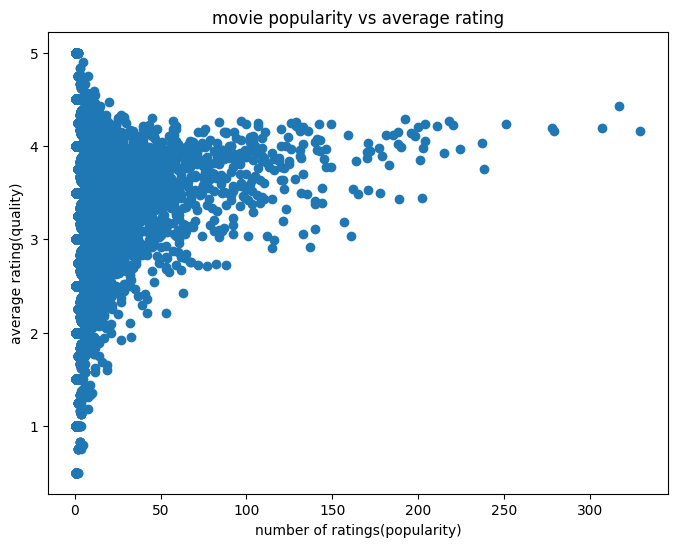

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(
     movie_stats["rating_count"],
     movie_stats["avg_ratings"] 
)
plt.xlabel("number of ratings(popularity)")
plt.ylabel("average rating(quality)")
plt.title("movie popularity vs average rating")
plt.show()


In [26]:
c=merged["rating"].mean()
c

np.float64(3.501556983616962)

In [27]:
m=50

In [28]:
movie_stats["weighted_rating"]=((movie_stats["rating_count"]/(movie_stats["rating_count"]+m))*movie_stats["avg_ratings"]+(m/(movie_stats["rating_count"]+m))*c)

In [29]:
movie_stats.sort_values("weighted_rating",ascending=False).head(10)

,avg_ratings,rating_count,weighted_rating
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,4.302664
Fight Club (1999),4.272936,218,4.129022
"Godfather, The (1972)",4.289062,192,4.126355
Star Wars: Episode IV - A New Hope (1977),4.231076,251,4.109893
Pulp Fiction (1994),4.197068,307,4.099658
"Usual Suspects, The (1995)",4.237745,204,4.092826
Schindler's List (1993),4.225000,220,4.091029
"Matrix, The (1999)",4.192446,278,4.087128
Star Wars: Episode V - The Empire Strikes Back (1980),4.215640,211,4.078842


In [30]:
top_movies=movie_stats.sort_values("weighted_rating",ascending=False)[["avg_ratings","rating_count","weighted_rating"]].head(10)
top_movies

,avg_ratings,rating_count,weighted_rating
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,4.302664
Fight Club (1999),4.272936,218,4.129022
"Godfather, The (1972)",4.289062,192,4.126355
Star Wars: Episode IV - A New Hope (1977),4.231076,251,4.109893
Pulp Fiction (1994),4.197068,307,4.099658
"Usual Suspects, The (1995)",4.237745,204,4.092826
Schindler's List (1993),4.225000,220,4.091029
"Matrix, The (1999)",4.192446,278,4.087128
Star Wars: Episode V - The Empire Strikes Back (1980),4.215640,211,4.078842


In [31]:
def recommend_movies(movie_stats,c,min_votes=50,top_n=10):
    m=min_votes
    movie_stats["weighted_rating"]=((movie_stats["rating_count"]/(movie_stats["rating_count"]+m))*movie_stats["avg_ratings"]+(m/(movie_stats["rating_count"]+m))*c)
    recomendations=movie_stats.sort_values("weighted_rating",ascending=False).head(top_n)
    return recomendations

In [32]:
recommend_movies(movie_stats,c)

,avg_ratings,rating_count,weighted_rating
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,4.302664
Fight Club (1999),4.272936,218,4.129022
"Godfather, The (1972)",4.289062,192,4.126355
Star Wars: Episode IV - A New Hope (1977),4.231076,251,4.109893
Pulp Fiction (1994),4.197068,307,4.099658
"Usual Suspects, The (1995)",4.237745,204,4.092826
Schindler's List (1993),4.225000,220,4.091029
"Matrix, The (1999)",4.192446,278,4.087128
Star Wars: Episode V - The Empire Strikes Back (1980),4.215640,211,4.078842


In [ ]:
top_movies = recommend_movies(movie_stats,c)
top_movies.reset_index(inplace=True)
top_movies = top_movies[[
    "title",
    "avg_ratings",
    "rating_count",
    "weighted_rating"
]]
top_movies

,title,avg_ratings,rating_count,weighted_rating
0,"Shawshank Redemption, The (1994)",4.429022,317,4.302664
1,Fight Club (1999),4.272936,218,4.129022
2,"Godfather, The (1972)",4.289062,192,4.126355
3,Star Wars: Episode IV - A New Hope (1977),4.231076,251,4.109893
4,Pulp Fiction (1994),4.197068,307,4.099658
5,"Usual Suspects, The (1995)",4.237745,204,4.092826
6,Schindler's List (1993),4.225000,220,4.091029
7,"Matrix, The (1999)",4.192446,278,4.087128
8,Star Wars: Episode V - The Empire Strikes Back...,4.215640,211,4.078842
9,Forrest Gump (1994),4.164134,329,4.076723
